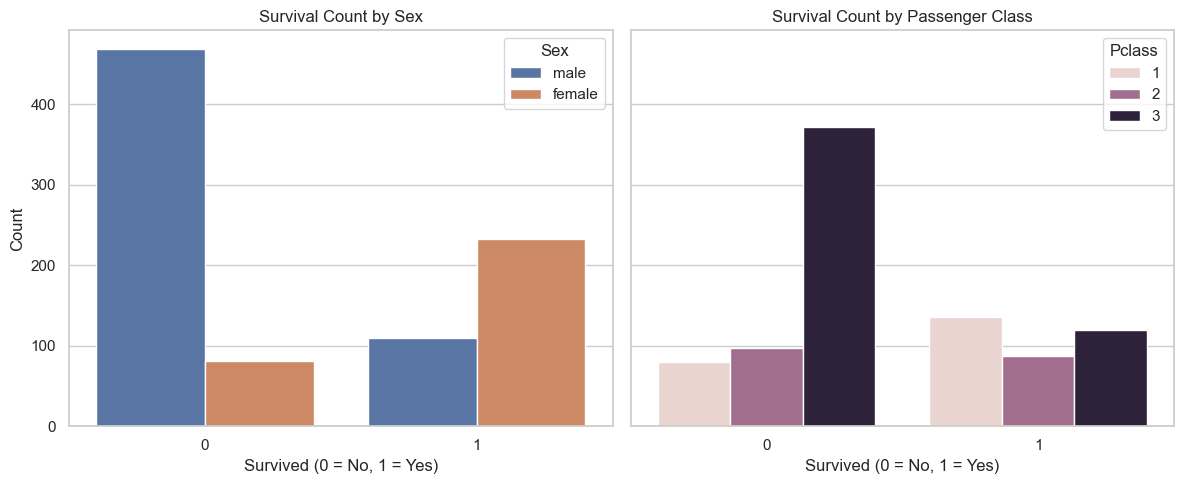

Validation Accuracy: 0.8044692737430168

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

✅ Submission file saved!


/var/folders/w7/lhmxsbwx4tb98f2k3b5pq1_40000gn/T/ipykernel_7943/1901366835.py:39: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(data['Age'].median(), inplace=True)
/var/folders/w7/lhmxsbwx4tb98f2k3b5pq1_40000gn/T/ipykernel_7943/1901366835.py:40: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting value

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# ----------------------------
# 1. Load Data
# ----------------------------
df = pd.read_csv("/Users/mia/Downloads/DS/titanic-ml/data/train.csv")

# ----------------------------
# 2. EDA
# ----------------------------
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.countplot(ax=axes[0], x="Survived", hue="Sex", data=df)
axes[0].set_title("Survival Count by Sex")
axes[0].set_xlabel("Survived (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")

sns.countplot(ax=axes[1], x="Survived", hue="Pclass", data=df)
axes[1].set_title("Survival Count by Passenger Class")
axes[1].set_xlabel("Survived (0 = No, 1 = Yes)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

# ----------------------------
# 3. Preprocessing Function
# ----------------------------
def preprocess(data, is_train=True):
    # Fill missing values
    data['Age'].fillna(data['Age'].median(), inplace=True)
    data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
    if not is_train:  # test set has Fare missing too
        data['Fare'].fillna(data['Fare'].median(), inplace=True)

    # Encode categorical features
    data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
    data['Embarked'] = data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

    # Drop unused columns
    data = data.drop(columns=['Name', 'Ticket', 'Cabin'])
    return data

df = preprocess(df)

# ----------------------------
# 4. Split Train/Test
# ----------------------------
X = df.drop(columns=['PassengerId', 'Survived'])
y = df['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# 5. Train Logistic Regression
# ----------------------------
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_val_pred = model.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

# ----------------------------
# 6. Train on Full Data
# ----------------------------
model.fit(X, y)

# ----------------------------
# 7. Prepare Test Set
# ----------------------------
df_test = pd.read_csv("/Users/mia/Downloads/DS/titanic-ml/data/test.csv")
df_test = preprocess(df_test, is_train=False)

X_test = df_test.drop(columns=['PassengerId'])

# Predict
y_pred_test = model.predict(X_test)

# ----------------------------
# 8. Submission File
# ----------------------------
submission = pd.DataFrame({
    "PassengerId": df_test["PassengerId"],
    "Survived": y_pred_test
})

submission.to_csv(
    "/Users/mia/Downloads/DS/titanic-ml/submission/submission.csv",
    index=False
)
print("✅ Submission file saved!")
